In [1]:
print(1+222)

223


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

In [3]:
file_path = 'D:/Programming/HUST/GoogleMap-Review-Scraping-and-Analysis/data/reviews.csv'
df = pd.read_csv(file_path)
print(f"Successfully loaded {len(df)} rows.")

Successfully loaded 947257 rows.


In [4]:
# count min, max, avr numbers of words and characters in reviews
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['text'].apply(lambda x: len(str(x)))
print(f"Word count - Min: {df['word_count'].min()}, Max: {df['word_count'].max()}, Avg: {df['word_count'].mean()}")
print(f"Character count - Min: {df['char_count'].min()}, Max: {df['char_count'].max()}, Avg: {df['char_count'].mean()}")

Word count - Min: 1, Max: 837, Avg: 28.74285331224789
Character count - Min: 10, Max: 4096, Avg: 160.61196486275637


In [11]:
# take random example of each rating (2 examples per rating, one short and one long)
short_reviews = df[df['word_count'] < df['word_count'].quantile(0.25)].groupby('rating').sample(n=1)
long_reviews = df[df['word_count'] > df['word_count'].quantile(0.75)].groupby('rating').sample(n=1)
random_examples = pd.concat([short_reviews, long_reviews]).sort_values(by='rating')
for _, row in random_examples.iterrows():
    print(f"Rating: {row['rating']}, Word Count: {row['word_count']}, Review: {row['text']}\n")
    

Rating: 1.0, Word Count: 6, Review: Diabetes on a tray move on...

Rating: 1.0, Word Count: 94, Review: I had a breakfast muffin which was grim.  Muffin was cold, bacon was tough, fried egg was cold and tough whilst the cheese didn't have enough heat from it's surroundings to melt it.  Sausage was warm and seemed fresh.  I did eat most of it as I as I was hungry and it was edible.  I mentioned this to the shift supervisor who cleared my plate and he did apologise but did nothing further.  I have had many of these breakfast muffins in a range of wetherspoons and this was by far the worst.

Rating: 2.0, Word Count: 48, Review: Meh place.  There was someone I was hanging out there with when I went a few months back.  They were what made the place fun.  My advice is find a person like that who will make you feel wonderful about everything, and then hit up Steins with them.

Rating: 2.0, Word Count: 7, Review: Croissants are good. Seafood nachos are decent.

Rating: 3.0, Word Count: 159, Re

In [6]:
review = "If I could give 12 stars, I would. Nick & Norman's in Senoia is just fantastic. We used to live in Senoia when they filmed the walking dead and used to frequent the restaurant on a regular basis. We would see the actors in here occasionally but didn't pay much attention because who wants to be bothered trying to eat right. One time, we got to have a good conversation with Norman Redus and Jeffrey Dean Morgan to the point where we actually asked them to sign our Harley Davidson. They were happy to do it. I bet they still remember, lol. Now, a few years later, living in a different state, whenever we get back to Senoia, we immediately come here for dinner. The food is perfect every time and delicious. We recently came to visit for a family wedding and went here first, and of course they didn't disappoint. I think we've been here a few dozen times and never a complaint. Its atmosphere is reminiscent of a speak-easy from a different time, warm and cozy. Go here when you're in town. You will remember and want to go back, and not just for the film status, but the place and the great food. We plan to move back to Senoia in the near future, and this will be the first celebration destination on arrival and many more to come. Good job guys!!"
print(len(str(review).split()))

235


In [24]:
df_train = pd.read_csv('D:/Programming/HUST/GoogleMap-Review-Scraping-and-Analysis/data/reviews_train.csv')
df_val = pd.read_csv('D:/Programming/HUST/GoogleMap-Review-Scraping-and-Analysis/data/reviews_val.csv')
df_test = pd.read_csv('D:/Programming/HUST/GoogleMap-Review-Scraping-and-Analysis/data/reviews_test.csv')

In [26]:
df_train['word_count'] = df_train['text'].apply(lambda x: len(str(x).split()))
df_val['word_count'] = df_val['text'].apply(lambda x: len(str(x).split()))
df_test['word_count'] = df_test['text'].apply(lambda x: len(str(x).split()))

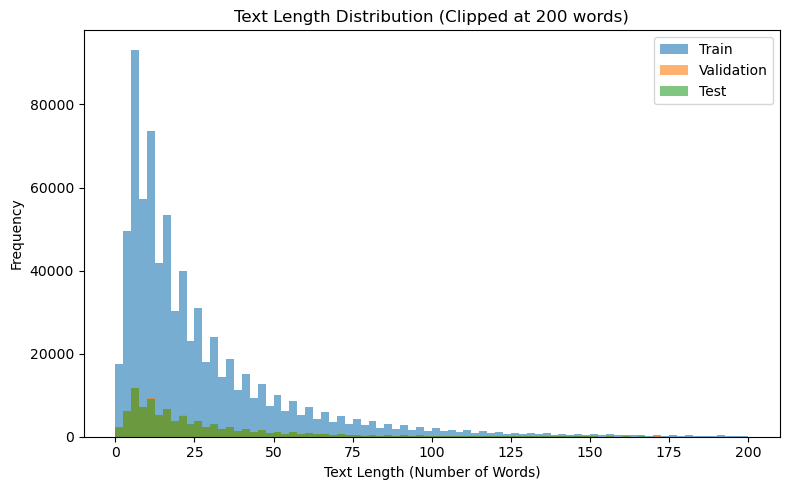

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    df_train["word_count"],
    bins=80,
    range=(0, 200),
    alpha=0.6,
    label="Train"
)

plt.hist(
    df_val["word_count"],
    bins=80,
    range=(0, 200),
    alpha=0.6,
    label="Validation"
)

plt.hist(
    df_test["word_count"],
    bins=80,
    range=(0, 200),
    alpha=0.6,
    label="Test"
)

plt.xlabel("Text Length (Number of Words)")
plt.ylabel("Frequency")
plt.title("Text Length Distribution (Clipped at 200 words)")
plt.legend()
plt.tight_layout()
plt.show()


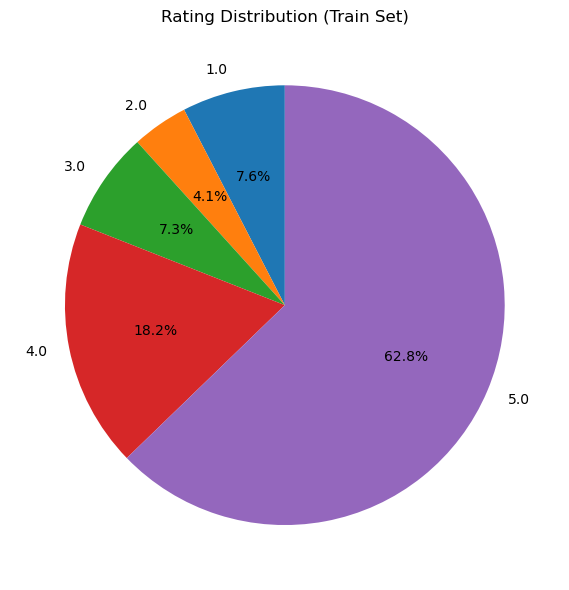

In [28]:
rating_counts = df_train["rating"].value_counts().sort_index()

labels = [
    "1.0",
    "2.0",
    "3.0",
    "4.0",
    "5.0"
]

plt.figure(figsize=(6, 6))
plt.pie(
    rating_counts,
    labels=labels,
    autopct="%.1f%%",
    startangle=90
)

plt.title("Rating Distribution (Train Set)")
plt.tight_layout()
plt.show()

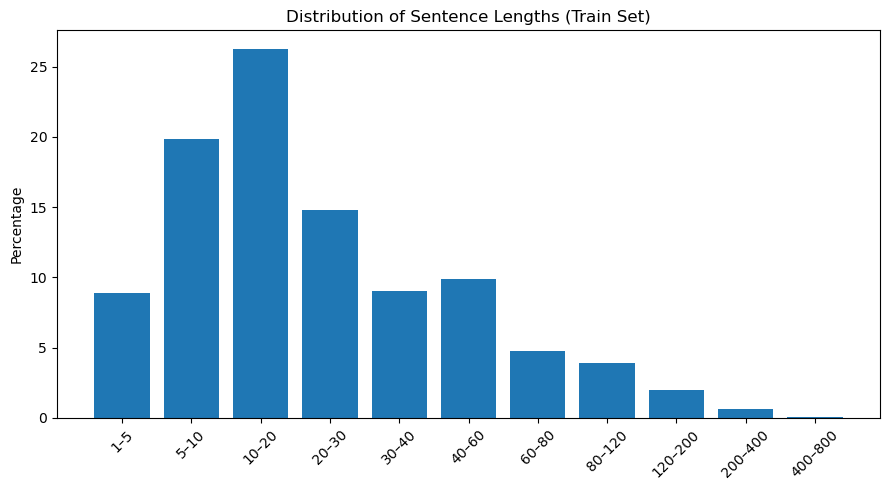

In [29]:
import numpy as np

bins = [1, 5, 10, 20, 30, 40, 60, 80, 120, 200, 400, 800]

counts, edges = np.histogram(df_train["word_count"], bins=bins)
percentages = counts / counts.sum() * 100

plt.figure(figsize=(9, 5))
plt.bar(
    range(len(percentages)),
    percentages
)

plt.xticks(
    range(len(percentages)),
    [f"{edges[i]}–{edges[i+1]}" for i in range(len(edges)-1)],
    rotation=45
)

plt.ylabel("Percentage")
plt.title("Distribution of Sentence Lengths (Train Set)")
plt.tight_layout()
plt.show()

preprocess

In [33]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import pickle
import re

def advanced_clean(text: str) -> str:
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    tokens = word_tokenize(text)
    cleaned_tokens = [
        lemmatizer.lemmatize(token) 
        for token in tokens 
        if token not in stop_words and len(token) > 2
    ]
    return " ".join(cleaned_tokens)

In [34]:
df_train['cleaned_text'] = df_train['text'].apply(advanced_clean)
df_val['cleaned_text'] = df_val['text'].apply(advanced_clean)
df_test['cleaned_text'] = df_test['text'].apply(advanced_clean)

df_train.to_csv('D:/Programming/HUST/GoogleMap-Review-Scraping-and-Analysis/data/reviews_train_cleaned.csv', index=False)
df_val.to_csv('D:/Programming/HUST/GoogleMap-Review-Scraping-and-Analysis/data/reviews_val_cleaned.csv', index=False)
df_test.to_csv('D:/Programming/HUST/GoogleMap-Review-Scraping-and-Analysis/data/reviews_test_cleaned.csv', index=False)

In [36]:
review = "Great little country pub. Excellent home cooked food at reasonable prices, good choice of ales, beers and ciders and friendly staff. Highly recommended 👍"

after_punc_remove_and_lower = re.sub(r'[^a-zA-Z\s]', '', review.lower())
print(after_punc_remove_and_lower +"\n")

after_stopword_removal = ' '.join([word for word in after_punc_remove_and_lower.split() if word not in stopwords.words('english') and len(word) > 2])
print(after_stopword_removal +"\n")

after_tokenization = word_tokenize(after_stopword_removal)
print(after_tokenization)

after_lemmatization = [WordNetLemmatizer().lemmatize(word) for word in after_tokenization]
print(after_lemmatization)

great little country pub excellent home cooked food at reasonable prices good choice of ales beers and ciders and friendly staff highly recommended 

great little country pub excellent home cooked food reasonable prices good choice ales beers ciders friendly staff highly recommended

['great', 'little', 'country', 'pub', 'excellent', 'home', 'cooked', 'food', 'reasonable', 'prices', 'good', 'choice', 'ales', 'beers', 'ciders', 'friendly', 'staff', 'highly', 'recommended']
['great', 'little', 'country', 'pub', 'excellent', 'home', 'cooked', 'food', 'reasonable', 'price', 'good', 'choice', 'ale', 'beer', 'cider', 'friendly', 'staff', 'highly', 'recommended']
